In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gamma
import networkx as nx

In [2]:
def make_complex(real, imag):
    return np.array(real) + 1j * np.array(imag)

In [3]:
def parse_dat(filename: str):
    def read_floats(n):
        return [float(f.readline().strip()) for _ in range(n)]

    def read_header():
        header = f.readline().strip().split()
        r, B, K, nf = header
        r, K, nf = int(r), int(K), int(nf)
        B = float(B)
        return r, B, K, nf

    def read_ij():
        i, j = map(int, f.readline().strip().split())
        return i, j

    with open(filename, 'r') as f:
        r, B, K, nf = read_header()

        S_hat = np.zeros((nf, r, r), dtype=complex)

        f.readline()
        frequencies = np.array(read_floats(nf))
        f.readline()

        for _ in range(r * (r + 1) // 2):
            i, j = read_ij()

            real = read_floats(nf)
            f.readline()
            imag = read_floats(nf)

            comp = make_complex(real, imag)
            S_hat[:, i - 1, j - 1] = comp
            S_hat[:, j - 1, i - 1] = comp.conjugate()
        return B, K, frequencies, S_hat


In [4]:
B, K, frequencies, S_hat = parse_dat("SDM_1.dat")
nf, _, r = S_hat.shape

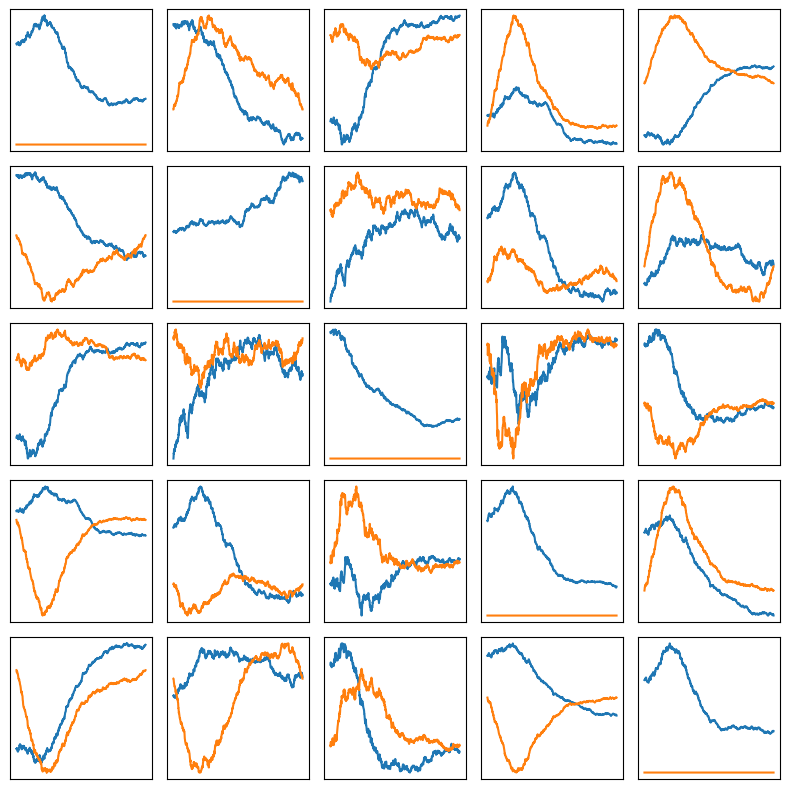

In [5]:
fig, axs = plt.subplots(r, r, figsize=(8, 8), tight_layout=True)

for i in range(r):
    for j in range(r):
        axs[i, j].plot(S_hat[:, i, j].real)
        axs[i, j].plot(S_hat[:, i, j].imag)
        axs[i, j].set_xticks([])
        axs[i, j].set_yticks([])

In [6]:
A = int(0.5 // B)

indices, = np.logical_and(
    B / 2 <= frequencies,
    frequencies <= 0.5 - B / 2
).nonzero()

frequency_grid_indices = np.linspace(indices[0], indices[-1], A).astype(int)
frequency_grid = frequencies[frequency_grid_indices]

In [7]:
S_hat_inv = np.linalg.inv(S_hat)
S_hat_inv_diag = S_hat_inv.diagonal(axis1=1, axis2=2)

In [8]:
partial_coherence = np.abs(S_hat_inv ** 2) / (S_hat_inv_diag[:, :, None] * S_hat_inv_diag[:, None, :])
assert np.allclose(partial_coherence.imag, 0)
partial_coherence = partial_coherence.real

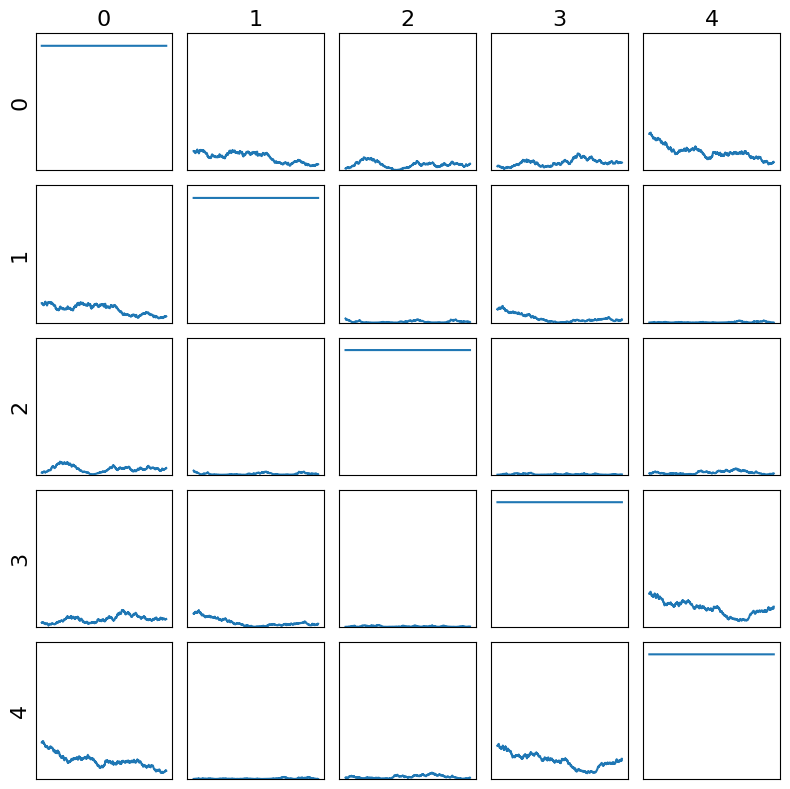

In [9]:
fig, axs = plt.subplots(r, r, figsize=(8, 8), tight_layout=True)

for i in range(r):
    axs[i, 0].set_ylabel(i, fontsize=16)
    axs[0, i].set_title(i, fontsize=16)
    
    for j in range(r):
        axs[i, j].plot(frequencies, partial_coherence[:, i, j])

        axs[i, j].set_xticks([])    
        axs[i, j].set_yticks([])

        axs[i, j].set_ylim(0, 1.1)

plt.savefig("figures/partial_coherences.pdf", bbox_inches="tight")

In [10]:
W = -2 * K * np.log(1 - partial_coherence[frequency_grid_indices]).sum(axis=0)

/var/folders/78/bkcwr2f5395cy1zsrtqv9ryh0000gn/T/ipykernel_69148/504731934.py:1: RuntimeWarning: divide by zero encountered in log
  W = -2 * K * np.log(1 - partial_coherence[frequency_grid_indices]).sum(axis=0)


In [11]:
ordered_W = []

for i in range(0, r):
    for j in range(i + 1, r):
        ordered_W.append(((i, j), W[i, j]))

ordered_W.sort(key = lambda x: x[1])
L = len(ordered_W)

In [12]:
alpha = 0.05
scale = 2*K / (K - (r - 1))

for k in range(L-1, -1, -1):
    l = k + 1
    (i, j), w = ordered_W[k]

    C_L = gamma.ppf(1 - alpha / l, a=A, scale=scale)
    if w < C_L:
        break

accepted_hypotheses = ordered_W[:l]
rejected_hypotheses = ordered_W[l:]

In [13]:
print(f"Edges in G")
for hyp in rejected_hypotheses:
    (i, j), w = hyp
    print(i, j)

print(f"Edges not in G")
for hyp in accepted_hypotheses:
    (i, j), w = hyp
    print(i, j)

Edges in G
2 4
1 3
0 2
0 3
0 1
0 4
3 4
Edges not in G
2 3
1 4
1 2


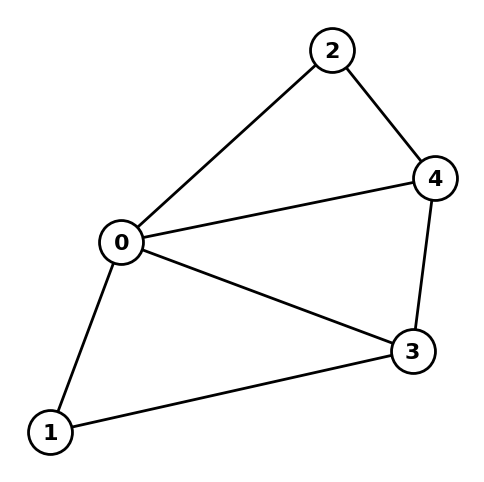

In [14]:
G = nx.Graph()
G.add_edges_from([edge for edge, _ in rejected_hypotheses])

pos = nx.spring_layout(G, seed=4)
label_pos = {k: (v[0], v[1] - 0.01) for k, v in pos.items()}

# Draw the graph
plt.figure(figsize=(6, 6))
nx.draw_networkx_nodes(G, pos, node_color='white', edgecolors="black", linewidths=2, node_size=1000)
nx.draw_networkx_edges(G, pos, edge_color='black', width=2)
nx.draw_networkx_labels(G, label_pos, font_size=16, font_weight="bold")

plt.axis('off')

plt.savefig("figures/graph.pdf")